# Age-Associated Divergence of Microbiome Composition Between BF and EU Samples

The original study found that the youngest BF and EU children clustered together, while the older children were more separated by population. They suggested that this could be related to breastfeeding and the switch to different diets. Here, I look at whether BF and EU microbiomes become more different with age using Aitchison distance.

This notebook tests whether microbiome differences between BF and EU children increase with age, extending the age-related clustering pattern observed in the original study.


### Import Libraries

In [9]:
suppressPackageStartupMessages({

########### main libraries ###########
library(SummarizedExperiment)
library(TreeSummarizedExperiment)
library(mia)
library(miaViz) # mia visualizatioon
library(vegan) # ecol stats (beta diversity)
library(ape) # reads trees

########### data manipulation tools ###########
library(tidyverse)
library(tibble)
library(scales)

########### visualization libraries ###########   
library(ggrepel)
library(patchwork)
library(scater)

library(knitr)

########### resource management tools ###########
# library(tictoc)

################ notes ####################
### loaded by tidyverse
# library(ggplot2)
# library(tidyr)
# library(dplyr)
# library(readr)
# library(stringr)

})

warnLevel <- getOption('warn')
options(warn = -1)

### Arguments Piped in with R script Conversion

In [8]:
args <- commandArgs(trailingOnly = TRUE)
if (length(args) >= 2) {
    PROJECT_NAME <- args[1]
    PROJECT_DIR  <- normalizePath(args[2])
} else {
    # defaults for notebook 
    PROJECT_NAME <- "ERP000133"
    PROJECT_DIR  <- normalizePath("..")
}

### Input File Paths (not piped in if R script)

In [7]:
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
ALPHA_DIV_DIR <-  file.path(ANALYSIS_DIR, "alpha_div")


In [13]:

tse <- readRDS( file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse.withAlphaDiv.rds")))
metadata <- as.data.frame(colData(tse))



### Make Output Directory

In [14]:
# make file output directory if it doesn't already exist
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
AGE_X_POP_DIR <-  file.path(ANALYSIS_DIR, "age_x_pop")
FIG_DIR <- file.path(PROJECT_DIR, "figures")
FIG_AGE_X_POP_DIR <- file.path(FIG_DIR, "age_x_pop")
dir.create(ANALYSIS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(AGE_X_POP_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_AGE_X_POP_DIR, recursive = TRUE, showWarnings = FALSE)

REPORT_TABLE_DIR <- file.path(PROJECT_DIR, "report_tables")
SUMMARY_TABLE_DIR <- file.path(PROJECT_DIR, "summary_tables") # more extensive tables not for the report go here
dir.create(REPORT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(SUMMARY_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)


QUARTO_PLOT_TABLE_DIR <- file.path(PROJECT_DIR, "quarto_plot_tables")
dir.create(QUARTO_PLOT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)

### Set Global Parameters

In [16]:
population_levels <- unique(colData(tse)$population_group)
# Dynamically assign colors to values in population_group
population_levels <- unique(colData(tse)$population_group)

population_colors <- setNames(
    grDevices::hcl.colors(
        length(population_levels),
        palette = "Dark 3"
    ),
    population_levels
)

# population_colors

In [17]:
baseSizeA = 16
titleSizeA = 18
dotSizeA = 4
axisTitleSizeA = 15
axisTextSizeA = 15
figureTitleSizeA = 25
legendTitleSizeA = 11

### Get metadata 

In [33]:
unique(metadata$age_years)

[1] 6 5 1 3 4 2

In [34]:
metadata$age_years

[1] 6 5 5 5 6 6 6 5 6 1 5 5 3 4 2 5 3 5 1 2 1 2 5 6 6 6 6 5 6

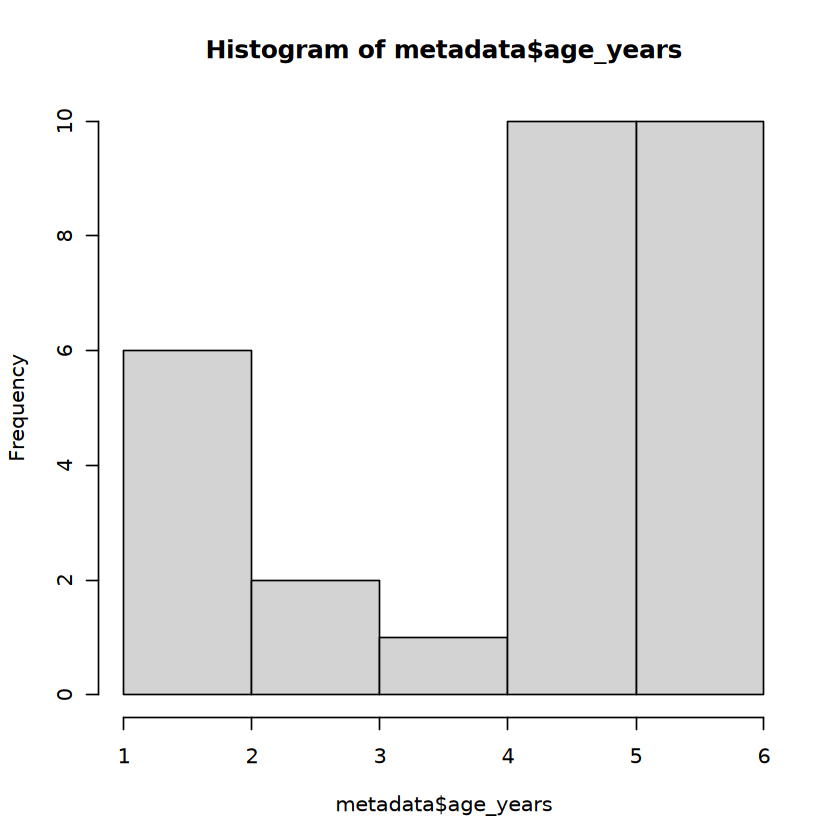

In [35]:
hist(metadata$age_years)

In [77]:

metadata_age <- as.data.frame(colData(tse)) |>
    mutate(
        sample_id = rownames(.),
        age = as.numeric(age_years),
        population_group = factor(population_group)
    )

# metadata_age

### Calculate Aitchison distance

In [23]:

# Centered Log-Ratio (CLR)  transform ASVs
tse_clr <- transformAssay(
    tse,
    assay.type = "counts",
    method = "clr",
    pseudocount = TRUE
)

# transpose the matrix 
clr_mat <- t(
    assay(tse_clr, "clr")
)


aitchison_dist <- dist(
    clr_mat,
    method = "euclidean"
)

A pseudocount of 1 was applied.



In [39]:
# make sure metadata are in the same order as the distance matrix
metadata_age <- metadata_age[
    attr(aitchison_dist, "Labels"),
]

### Run PERMANOVA

In [41]:
age_permanova <- adonis2(
    aitchison_dist ~ population_group * age,
    data = metadata_age,
    permutations = 9999,
    by = "margin"
)

In [42]:
age_permanova

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
population_group:age,1,1486.885,0.04139646,1.336837,0.073
Residual,25,27806.025,0.77414957,NA,NA
Total,28,35918.156,1.00000000,NA,NA


### Visualize relationship

In [44]:
# convert distance ob to matrix
aitchison_mat <- as.matrix(aitchison_dist)

In [45]:
# make sure metadata match matrix order
metadata_age <- metadata_age[
    rownames(aitchison_mat),
    ,
    drop = FALSE
]

In [48]:
# for each sample, calculate mean distance to samples
#                  from the other population


metadata_age$mean_cross_population_distance <- NA

for (i in seq_len(nrow(metadata_age))) {

    other_population <- metadata_age$population_group != metadata_age$population_group[i]

    metadata_age$mean_cross_population_distance[i] <- mean(
        aitchison_mat[i, other_population],
        na.rm = TRUE
    )
}

In [50]:
metadata_age$mean_cross_population_distance

[1] 54.21644 54.92111 48.43352 47.25460 51.96511 50.40749 55.21312 52.78851
 [9] 46.61876 50.55867 50.85083 53.26869 53.02196 53.74432 44.36730 60.36595
[17] 56.76592 55.67774 45.97916 48.52166 47.34701 49.57058 57.95737 56.59023
[25] 57.26143 57.71639 59.75500 55.99409 52.99388

In [61]:
# get label thing for plot 

interaction_results <- age_permanova["population_group:age", ]

interaction_label <- paste0(
    "PERMANOVA\nPopulation × Age\n",
    "R² = ", sprintf("%.3f", interaction_results$R2),
    ", F = ", sprintf("%.2f", interaction_results$F),
    ", p = ", sprintf("%.3f", interaction_results$`Pr(>F)`)
)



In [66]:
metadata_age

,group,run_id,population_group,age_years,sex,reported_ethnicity,antibiotic_history,delivery_mode,clinical_status,location,⋯,chao1,chao1_se,shannon,simpson,gini_simpson,inverse_simpson,faith,sample_id,age,mean_cross_population_distance
,<chr>,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
10BF,BF,ERR011058,BF,6,female,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,90,0,2.871182,0.07272873,0.8472253,6.545585,8.818393,10BF,6,54.21644
10EU,EU,ERR011059,EU,5,male,caucasian,more than 6 months since last use,natural childbirth,healthy,"Italy:Toscany, Florence",⋯,128,0,4.013306,0.23250223,0.9663982,29.760285,10.091941,10EU,5,54.92111
11BF,BF,ERR011060,BF,5,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,55,0,1.934080,0.06017715,0.6978618,3.309744,6.035551,11BF,5,48.43352
11EU,EU,ERR011061,EU,5,male,caucasian,more than 6 months since last use,natural childbirth,healthy,"Italy:Toscany, Florence",⋯,56,0,2.461631,0.09988552,0.8212239,5.593589,5.734657,11EU,5,47.25460
12BF,BF,ERR011062,BF,6,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,76,0,1.929808,0.03625144,0.6370380,2.755109,8.100489,12BF,6,51.96511
12EU,EU,ERR011063,EU,6,male,caucasian,more than 6 months since last use,natural childbirth,healthy,"Italy:Toscany, Florence",⋯,87,0,3.451106,0.18409155,0.9375623,16.015965,7.234261,12EU,6,50.40749
13BF,BF,ERR011064,BF,6,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,96,0,3.230823,0.09895835,0.8947369,9.500001,9.288940,13BF,6,55.21312
13EU,EU,ERR011065,EU,5,male,caucasian,more than 6 months since last use,natural childbirth,healthy,"Italy:Toscany, Florence",⋯,85,0,3.383899,0.18278760,0.9356373,15.536946,7.293917,13EU,5,52.78851
15BF,BF,ERR011066,BF,6,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,39,0,2.038892,0.12019454,0.7866706,4.687587,5.049746,15BF,6,46.61876


`geom_smooth()` using formula = 'y ~ x'


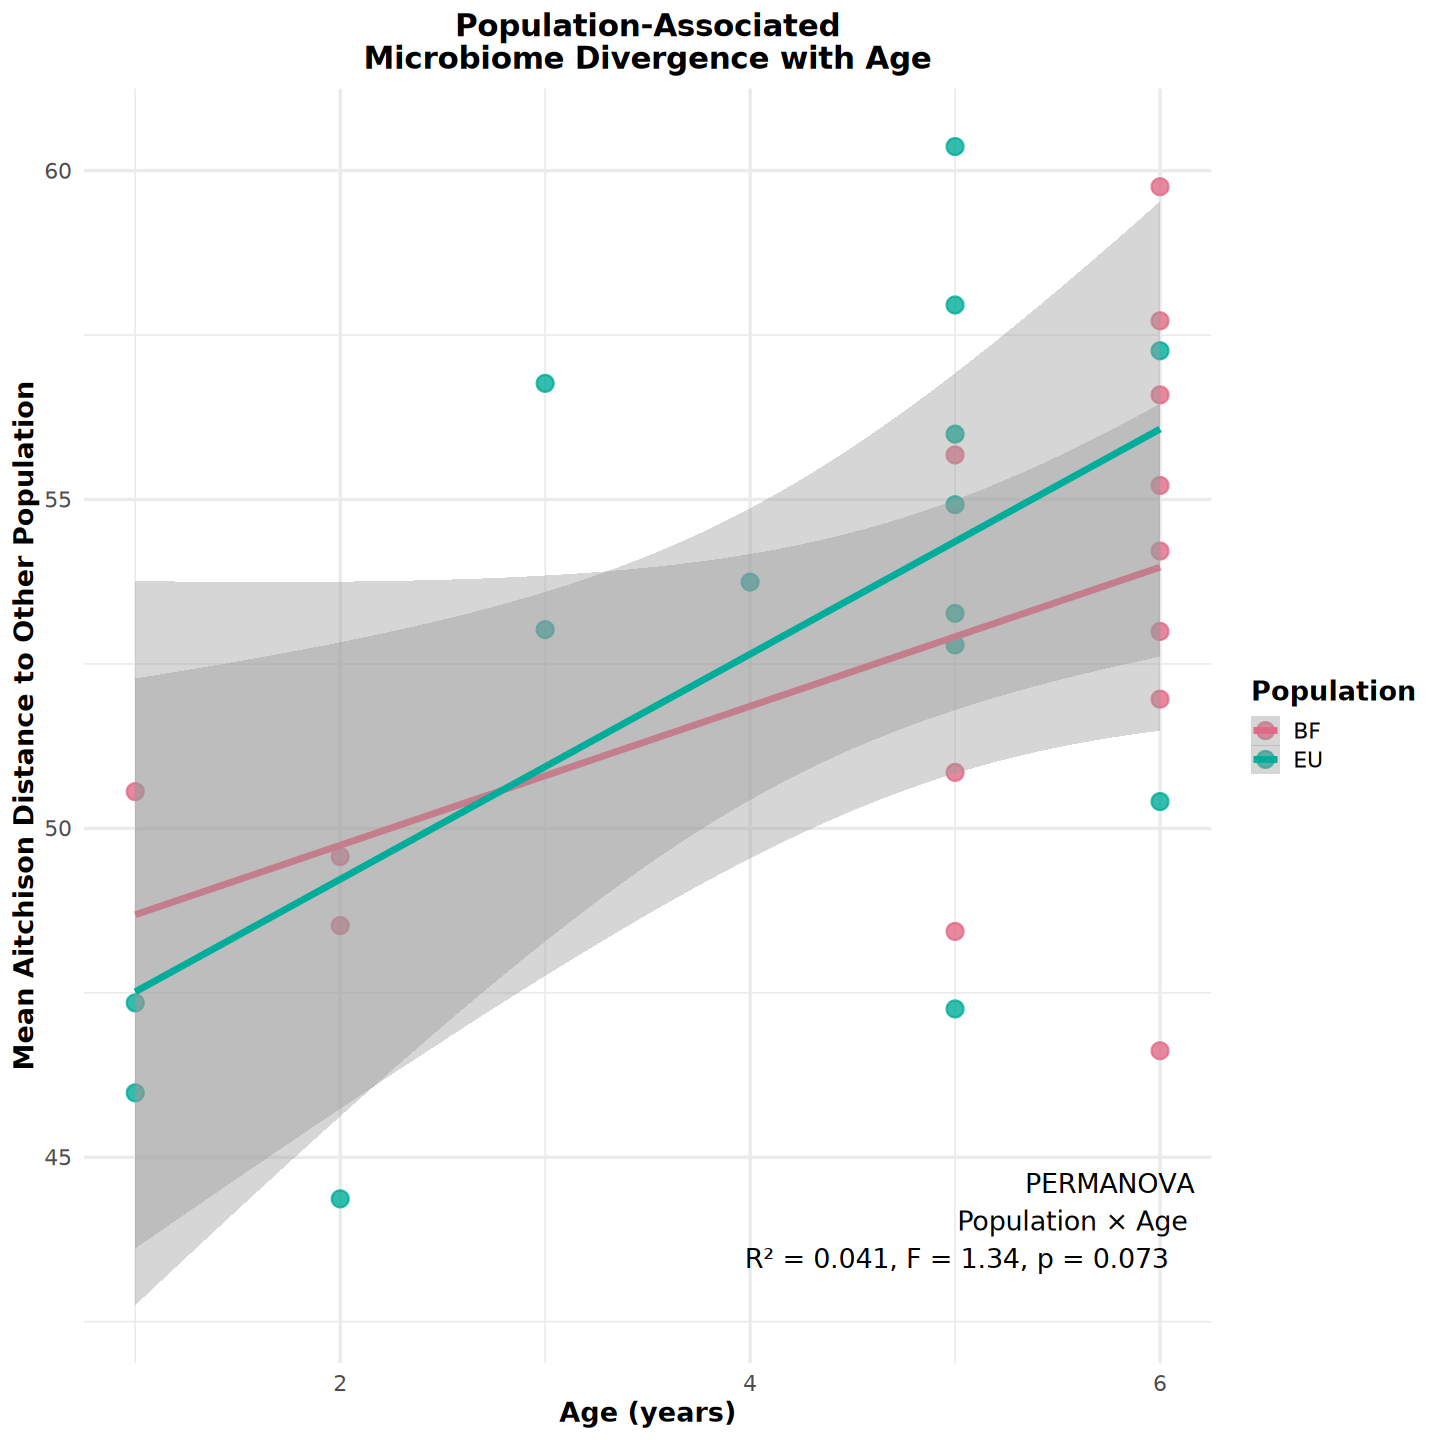

In [65]:
options(repr.plot.width = 12, repr.plot.height = 12)
label = "Population × Age\nR² = 0.041, F = 1.34, p = 0.073"


p_age_distance <- ggplot(
    metadata_age,
    aes(
        x = age,
        y = mean_cross_population_distance,
        color = population_group
    )
) +
    geom_point(
        size = 4,
        alpha = 0.8
    ) +
    geom_smooth(
        method = "lm",
        se = TRUE
    ) +
    scale_color_manual(values = population_colors) +
    annotate(
        "text",
        x = Inf,
        y = -Inf,
        label = interaction_label,
        hjust = 1.1,
        vjust = -1,
        size = 5.5,
        color = "black"
    ) +
    labs(
        title = "Population-Associated\nMicrobiome Divergence with Age",
        x = "Age (years)",
        y = "Mean Aitchison Distance to Other Population",
        color = "Population"
    ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(
            face = "bold",
            hjust = 0.5,
            size = 18
        ),
        axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold")
    )

p_age_distance

In [72]:



ggsave(
    filename = paste0(FIG_AGE_X_POP_DIR, '/', PROJECT_NAME, '.age_x_pop.meanAitchison_distance.png'),
    plot = p_age_distance,
    width = 10,
    height = 10,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_AGE_X_POP_DIR, '/', PROJECT_NAME, '.age_x_pop.meanAitchison_distance.pdf'),
    plot = p_age_distance,
    width = 12,
    height = 12,
    units = "in",
    bg = "white"
)


# save table for quarto plot
write_tsv( 
    metadata_age,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".age_x_pop.meanAitchison_distance_with_metadata_age.tsv")),
    quote = "needed"
)


















`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


### Dispersion check

In [70]:
# Test homogeneity of dispersion between populations

pop_dispersion <- betadisper(
    aitchison_dist,
    metadata_age$population_group
)

pop_dispersion_test <- permutest(
    pop_dispersion,
    permutations = 9999
)

In [75]:
dispersion_results <- as.data.frame(
    pop_dispersion_test$tab
)

dispersion_results$term <- rownames(dispersion_results)

dispersion_results <- dispersion_results |>
    select(
        term,
        Df,
        `Sum Sq`,
        `Mean Sq`,
        F,
        `Pr(>F)`
    )

dispersion_results

,term,Df,Sum Sq,Mean Sq,F,Pr(>F)
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,Groups,1,138.8824,138.88240,6.621432,0.015
Residuals,Residuals,27,566.3163,20.97468,NA,NA


In [74]:

# save table for quarto plot
write_tsv( 
    dispersion_results,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".age_x_pop.beta_dispersion_results.tsv")),
    quote = "needed"
)


